In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pandas as pd
import os, math, cv2

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, classification_report,
    average_precision_score, accuracy_score,
    f1_score, precision_score, recall_score
)
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, LearningRateScheduler
)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-04-27 06:39:51.284303: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777271991.464555      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777271991.525398      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 2.18.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
data_dir = r"/kaggle/input/eye-diseases-classification/dataset"

filepaths, labels = [], []
for fold in os.listdir(data_dir):
    foldpath = os.path.join(data_dir, fold)
    if not os.path.isdir(foldpath):
        continue
    for file in os.listdir(foldpath):
        filepaths.append(os.path.join(foldpath, file))
        labels.append(fold)

df = pd.concat([
    pd.Series(filepaths, name='filepaths'),
    pd.Series(labels,    name='labels')
], axis=1)

print("Class distribution:")
print(df['labels'].value_counts())
print(f"\nTotal samples : {len(df)}")
print(f"Unique classes: {df['labels'].nunique()}")

# Encode classes
class_names = sorted(df['labels'].unique().tolist())
num_classes  = len(class_names)
label2idx    = {c: i for i, c in enumerate(class_names)}
df['label_idx'] = df['labels'].map(label2idx)
print("\nClass → index mapping:", label2idx)

Class distribution:
labels
diabetic_retinopathy    1098
normal                  1074
cataract                1038
glaucoma                1007
Name: count, dtype: int64

Total samples : 4217
Unique classes: 4

Class → index mapping: {'cataract': 0, 'diabetic_retinopathy': 1, 'glaucoma': 2, 'normal': 3}


In [3]:

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 100           # max epochs; EarlyStopping will cut short
INIT_LR     = 1e-3         # initial LR for head
FINETUNE_LR = 1e-4         # LR for fine-tuning backbone
WEIGHT_DECAY= 1e-4
LABEL_SMOOTH= 0.1
N_FOLDS     = 5
PATIENCE    = 8
UNFREEZE_FROM = -50        # unfreeze last 50 layers during fine-tune phase


# Heavy augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.8, 1.2],
    channel_shift_range=20.0,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)  # no augmentation for val/test

print("Hyperparameters configured.")
print(f"  Image size   : {IMG_SIZE}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Epochs (max) : {EPOCHS}")
print(f"  K-Folds      : {N_FOLDS}")
print(f"  Label smooth : {LABEL_SMOOTH}")

Hyperparameters configured.
  Image size   : (224, 224)
  Batch size   : 32
  Epochs (max) : 100
  K-Folds      : 5
  Label smooth : 0.1


In [4]:

def build_densenet201(num_classes, trainable_base=False):
    """
    Build DenseNet201 with a custom classification head.

    Architecture changes vs. vanilla DenseNet201:
      • GlobalAveragePooling2D  → rich spatial aggregation
      • Dense(512, relu) + BN + Dropout(0.4)  → powerful head
      • Dense(256, relu) + BN + Dropout(0.25) → bottleneck
      • Dense(num_classes, softmax)            → output
    """
    base = DenseNet201(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base.trainable = trainable_base  # freeze backbone initially

    inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name='input')
    x = base(inputs, training=False)               # BatchNorm in eval mode

    # ── Custom head ──────────────────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D(name='gap')(x)

    x = layers.Dense(512, name='fc1')(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4, name='drop1')(x)

    x = layers.Dense(256, name='fc2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.25, name='drop2')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)
    # ─────────────────────────────────────────────────────────────────────────

    model = keras.Model(inputs, outputs, name='DenseNet201_EyeDisease')
    return model, base


# Quick sanity check
_m, _b = build_densenet201(num_classes)
print(f"DenseNet201 model parameters : {_m.count_params():,}")
print(f"Backbone layers              : {len(_b.layers)}")
del _m, _b

I0000 00:00:1777272032.673086      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
DenseNet201 model parameters : 19,440,964
Backbone layers              : 707


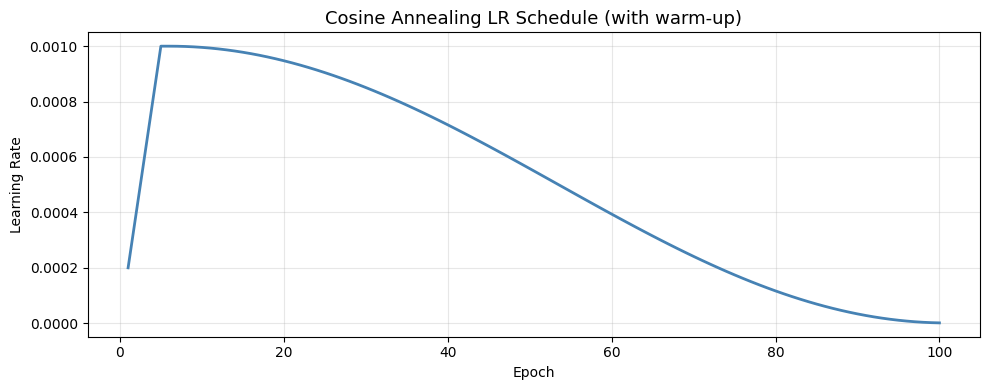

LR schedule plotted.


In [5]:

def cosine_annealing_with_warmup(epoch, lr,
                                  warmup_epochs=5,
                                  total_epochs=EPOCHS,
                                  eta_min=1e-6,
                                  eta_max=INIT_LR):
    """
    Linear warm-up for `warmup_epochs`, then cosine decay to eta_min.
    Provides smooth LR transition that helps DenseNets converge well.
    """
    if epoch < warmup_epochs:
        return eta_max * (epoch + 1) / warmup_epochs  # linear warm-up
    progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    return eta_min + 0.5 * (eta_max - eta_min) * (1 + math.cos(math.pi * progress))


# Visualise the schedule
lrs = [cosine_annealing_with_warmup(e, None) for e in range(EPOCHS)]
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS + 1), lrs, linewidth=2, color='steelblue')
plt.title('Cosine Annealing LR Schedule (with warm-up)', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("LR schedule plotted.")

In [6]:

def plot_history(history, title='DenseNet201'):
    tr_acc  = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    tr_loss = history.history['loss']
    val_loss= history.history['val_loss']

    best_loss_ep = np.argmin(val_loss) + 1
    best_acc_ep  = np.argmax(val_acc)  + 1

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    epochs = range(1, len(tr_acc) + 1)

    axes[0].plot(epochs, tr_loss,  label='Train Loss',  linewidth=2)
    axes[0].plot(epochs, val_loss, label='Val Loss',    linewidth=2)
    axes[0].scatter(best_loss_ep, val_loss[best_loss_ep-1], s=120, zorder=5, label=f'Best @ ep{best_loss_ep}')
    axes[0].set_title(f'{title} — Loss',     fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, tr_acc,  label='Train Accuracy', linewidth=2)
    axes[1].plot(epochs, val_acc, label='Val Accuracy',   linewidth=2)
    axes[1].scatter(best_acc_ep, val_acc[best_acc_ep-1], s=120, zorder=5, label=f'Best @ ep{best_acc_ep}')
    axes[1].set_title(f'{title} — Accuracy', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

    print(f"Best val loss {min(val_loss):.4f} @ epoch {best_loss_ep}")
    print(f"Best val acc  {max(val_acc):.4f}  @ epoch {best_acc_ep}")


# ─── Confusion Matrix ─────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, class_names, title='DenseNet201'):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, None]
    annot = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.3f})'
                       for j in range(cm.shape[1])]
                      for i in range(cm.shape[0])])

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {title}', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()
    return cm



def print_report(y_true, y_pred, class_names, model_name='DenseNet201'):
    report = classification_report(y_true, y_pred, target_names=class_names,
                                   digits=4, output_dict=True)
    print(f"\n{'='*80}")
    print(f"CLASSIFICATION REPORT — {model_name}")
    print(f"{'='*80}")
    print(f"{'Class':<20} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
    print("-"*80)
    for cls in class_names:
        m = report[cls]
        print(f"{cls:<20} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1-score']:>10.4f} {int(m['support']):>10}")
    print("-"*80)
    for avg in ['macro avg', 'weighted avg']:
        m = report[avg]
        print(f"{avg:<20} {m['precision']:>10.4f} {m['recall']:>10.4f} {m['f1-score']:>10.4f} {int(m['support']):>10}")
    print(f"\nOverall Accuracy: {report['accuracy']:.4f}")
    print('='*80)
    return report


# ─── GradCAM ─────────────────────────────────────────────────────────────────

def plot_gradcam(model, test_gen, class_names, n=4):
    import numpy as np
    import tensorflow as tf
    import matplotlib.pyplot as plt
    import cv2

    LAST_CONV = 'conv5_block32_2_conv'

    # ✅ find backbone
    base_model = None
    for layer in model.layers:
        if hasattr(layer, 'layers'):
            base_model = layer
            break

    if base_model is None:
        print("Could not locate backbone — skipping GradCAM.")
        return

    # ✅ get conv layer
    try:
        conv_layer = base_model.get_layer(LAST_CONV)
    except:
        conv_layers = [l for l in base_model.layers if 'Conv2D' in l.__class__.__name__]
        conv_layer = conv_layers[-1]
        LAST_CONV = conv_layer.name

    grad_model = tf.keras.models.Model(
        base_model.input,
        [conv_layer.output, base_model.output]
    )

    test_gen.reset()
    images, labels_oh = next(iter(test_gen))

    fig, axes = plt.subplots(2, n, figsize=(5*n, 10))
    fig.suptitle('GradCAM — DenseNet201', fontsize=16, fontweight='bold')

    for i in range(min(n, len(images))):
        img = images[i]
        img_exp = np.expand_dims(img, 0)

        true_cls = class_names[np.argmax(labels_oh[i])]

        preds = model.predict(img_exp, verbose=0)
        pred_idx = np.argmax(preds[0])
        pred_cls = class_names[pred_idx]
        conf = np.max(preds[0])

        # ✅ GradCAM
        with tf.GradientTape() as tape:
            conv_out, bb_preds = grad_model(img_exp)
            loss = tf.gather(bb_preds[0], pred_idx)   # ✅ FIX

        grads = tape.gradient(loss, conv_out)

        if grads is None:
            print("Skipping image due to None gradients")
            continue

        pooled = tf.reduce_mean(grads, axis=(0, 1, 2))

        heatmap = conv_out[0] @ pooled[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)

        heatmap = tf.maximum(heatmap, 0)
        heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
        heatmap = heatmap.numpy()

        heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

        # 🔹 Plot original
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'True: {true_cls}', fontsize=10)
        axes[0, i].axis('off')

        # 🔹 Plot GradCAM
        axes[1, i].imshow(img)
        axes[1, i].imshow(heatmap, cmap='jet', alpha=0.45)

        color = 'green' if pred_cls == true_cls else 'red'
        axes[1, i].set_title(f'Pred: {pred_cls} ({conf:.2f})',
                             fontsize=10, color=color)
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()


print("Utility functions defined.")

Utility functions defined.


In [7]:

train_val_df, test_df = train_test_split(
    df, test_size=0.10, stratify=df['labels'], random_state=42, shuffle=True
)

print(f"Train+Val samples : {len(train_val_df)}")
print(f"Test samples      : {len(test_df)}")
print("\nTest class distribution:")
print(test_df['labels'].value_counts())

Train+Val samples : 3795
Test samples      : 422

Test class distribution:
labels
diabetic_retinopathy    110
normal                  107
cataract                104
glaucoma                101
Name: count, dtype: int64



  FOLD 1 / 5
  Train: 3036  |  Val: 759
Found 3036 validated image filenames belonging to 4 classes.
Found 759 validated image filenames belonging to 4 classes.
  [Phase 1] Training head (backbone frozen) ...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1777272129.385937     100 service.cc:148] XLA service 0x797b184e9ed0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777272129.386773     100 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777272134.153961     100 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/95 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.2578 - loss: 1.6759 - top2_acc: 0.5156    

I0000 00:00:1777272153.594688     100 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


95/95 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.5833 - loss: 1.1462 - top2_acc: 0.7821 - val_accuracy: 0.6825 - val_loss: 0.8817 - val_top2_acc: 0.9328 - learning_rate: 3.3333e-04
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 62s 651ms/step - accuracy: 0.7591 - loss: 0.8381 - top2_acc: 0.9210 - val_accuracy: 0.7075 - val_loss: 0.9503 - val_top2_acc: 0.8880 - learning_rate: 6.6667e-04
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 637ms/step - accuracy: 0.7809 - loss: 0.7809 - top2_acc: 0.9299 - val_accuracy: 0.7523 - val_loss: 0.8517 - val_top2_acc: 0.9433 - learning_rate: 0.0010
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 645ms/step - accuracy: 0.8310 - loss: 0.7150 - top2_acc: 0.9552 - val_accuracy: 0.7813 - val_loss: 0.7987 - val_top2_acc: 0.9289 - learning_rate: 0.0010
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 638ms/step - accuracy: 0.8246 - loss: 0.7052 - top2_acc: 0.9579 - val_accuracy: 0.8248 - val_loss: 0.7363 - val_top2_acc: 0.9526 - learning_rate: 9.8313e-04
Epoch 6/15
95/95 ━━━━━━━━━

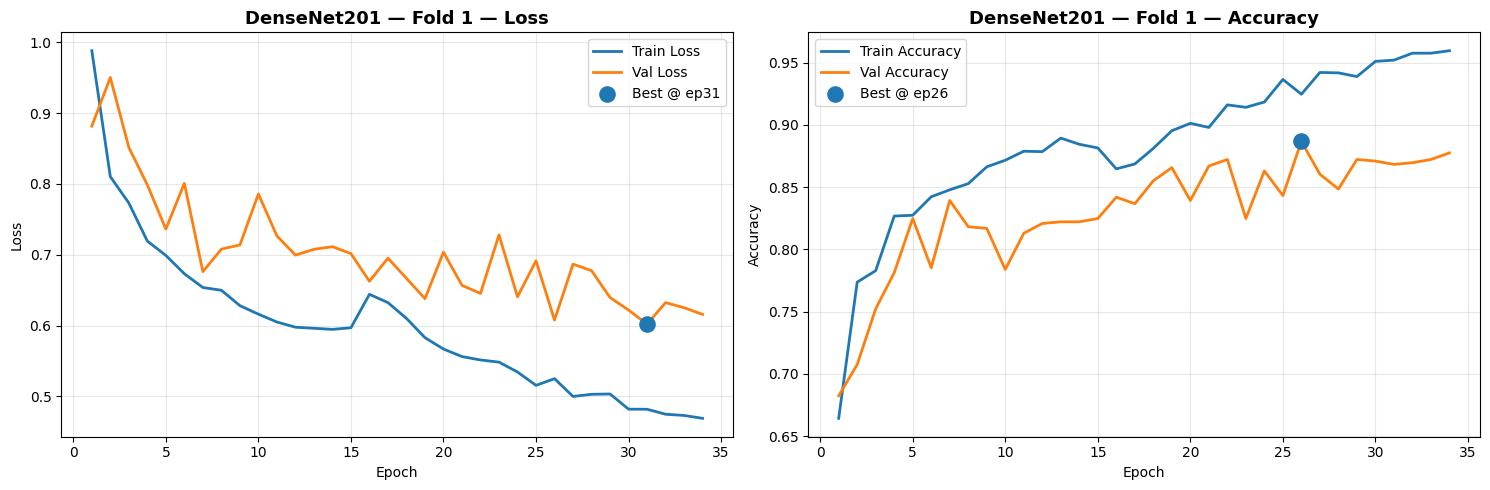

Best val loss 0.6019 @ epoch 31
Best val acc  0.8867  @ epoch 26
  ★ New best model (fold 1) — val_acc=0.8867

  FOLD 2 / 5
  Train: 3036  |  Val: 759
Found 3036 validated image filenames belonging to 4 classes.
Found 759 validated image filenames belonging to 4 classes.
  [Phase 1] Training head (backbone frozen) ...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.5545 - loss: 1.1999 - top2_acc: 0.7872 - val_accuracy: 0.7154 - val_loss: 0.8797 - val_top2_acc: 0.9038 - learning_rate: 3.3333e-04
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 65s 682ms/step - accuracy: 0.7488 - loss: 0.8398 - top2_acc: 0.9246 - val_accuracy: 0.7536 - val_loss: 0.8212 - val_top2_acc: 0.9368 - learning_rate: 6.6667e-04
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 60s 637ms/step - accuracy: 0.7886 - loss: 0.7729 - top2_acc: 0.9398 - val_accuracy: 0.6785 - val_loss: 1.0651 - val_top2_acc: 0.9328 - learning_rate: 0.0010
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 60s 635ms/step - accuracy: 0.7924 - loss: 0.7554 - top2_acc: 0.9479 - val_accuracy: 0.7470 - val_loss: 0.8487 - val_top2_acc: 0.9631 - learning_rate: 0.0010
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 638ms/step - accuracy: 0.8273 - loss: 0.6982 - top2_acc: 0.9559 - val_accuracy: 0.8235 - val_loss: 0.6783 - val_top2_acc: 0.9657 - learning_rate: 9.8313e-04
Epoch 6/15
95/9

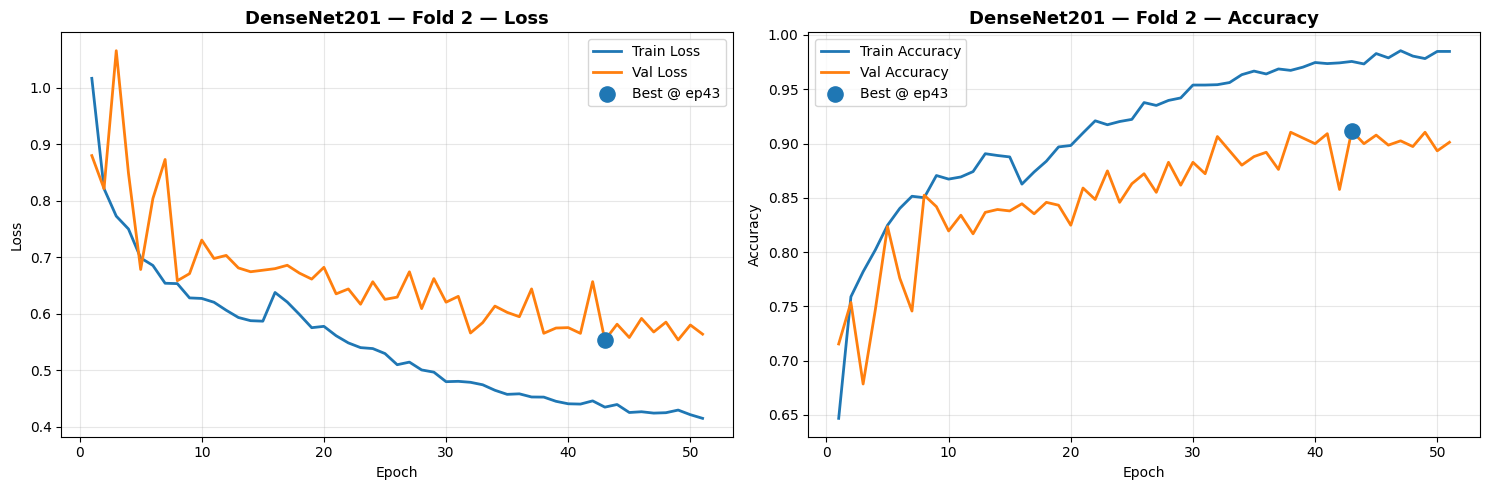

Best val loss 0.5534 @ epoch 43
Best val acc  0.9117  @ epoch 43
  ★ New best model (fold 2) — val_acc=0.9117

  FOLD 3 / 5
  Train: 3036  |  Val: 759
Found 3036 validated image filenames belonging to 4 classes.
Found 759 validated image filenames belonging to 4 classes.
  [Phase 1] Training head (backbone frozen) ...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.5802 - loss: 1.1430 - top2_acc: 0.8127 - val_accuracy: 0.6970 - val_loss: 0.9221 - val_top2_acc: 0.8788 - learning_rate: 3.3333e-04
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 62s 652ms/step - accuracy: 0.7450 - loss: 0.8636 - top2_acc: 0.9123 - val_accuracy: 0.6917 - val_loss: 0.9428 - val_top2_acc: 0.9144 - learning_rate: 6.6667e-04
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 640ms/step - accuracy: 0.7706 - loss: 0.7984 - top2_acc: 0.9408 - val_accuracy: 0.6785 - val_loss: 1.1248 - val_top2_acc: 0.9170 - learning_rate: 0.0010
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 640ms/step - accuracy: 0.8193 - loss: 0.7234 - top2_acc: 0.9487 - val_accuracy: 0.8090 - val_loss: 0.7408 - val_top2_acc: 0.9433 - learning_rate: 0.0010
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 644ms/step - accuracy: 0.8137 - loss: 0.7079 - top2_acc: 0.9540 - val_accuracy: 0.8116 - val_loss: 0.7461 - val_top2_acc: 0.9552 - learning_rate: 9.8313e-04
Epoch 6/15
95/9

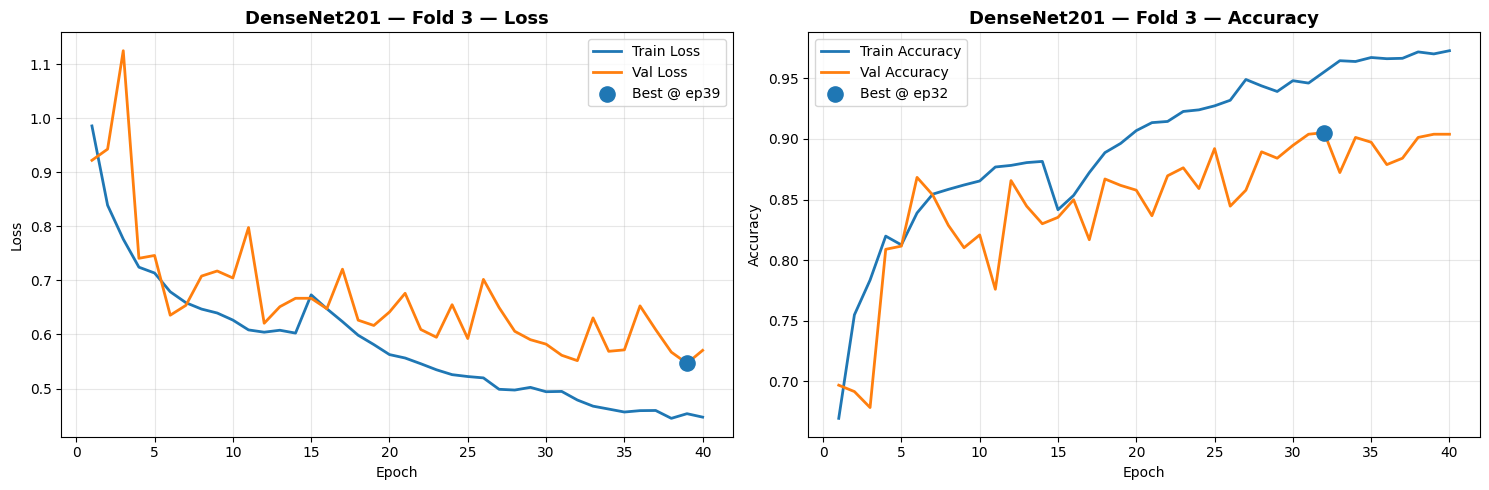

Best val loss 0.5466 @ epoch 39
Best val acc  0.9051  @ epoch 32

  FOLD 4 / 5
  Train: 3036  |  Val: 759
Found 3036 validated image filenames belonging to 4 classes.
Found 759 validated image filenames belonging to 4 classes.
  [Phase 1] Training head (backbone frozen) ...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.5830 - loss: 1.1379 - top2_acc: 0.7973 - val_accuracy: 0.6838 - val_loss: 0.9067 - val_top2_acc: 0.9236 - learning_rate: 3.3333e-04
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 63s 660ms/step - accuracy: 0.7572 - loss: 0.8267 - top2_acc: 0.9289 - val_accuracy: 0.7431 - val_loss: 0.8208 - val_top2_acc: 0.9275 - learning_rate: 6.6667e-04
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 62s 657ms/step - accuracy: 0.7768 - loss: 0.7842 - top2_acc: 0.9358 - val_accuracy: 0.8235 - val_loss: 0.7282 - val_top2_acc: 0.9499 - learning_rate: 0.0010
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 62s 650ms/step - accuracy: 0.8066 - loss: 0.7204 - top2_acc: 0.9570 - val_accuracy: 0.8340 - val_loss: 0.7014 - val_top2_acc: 0.9552 - learning_rate: 0.0010
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 62s 653ms/step - accuracy: 0.8206 - loss: 0.6994 - top2_acc: 0.9659 - val_accuracy: 0.8050 - val_loss: 0.7321 - val_top2_acc: 0.9354 - learning_rate: 9.8313e-04
Epoch 6/15
95/9

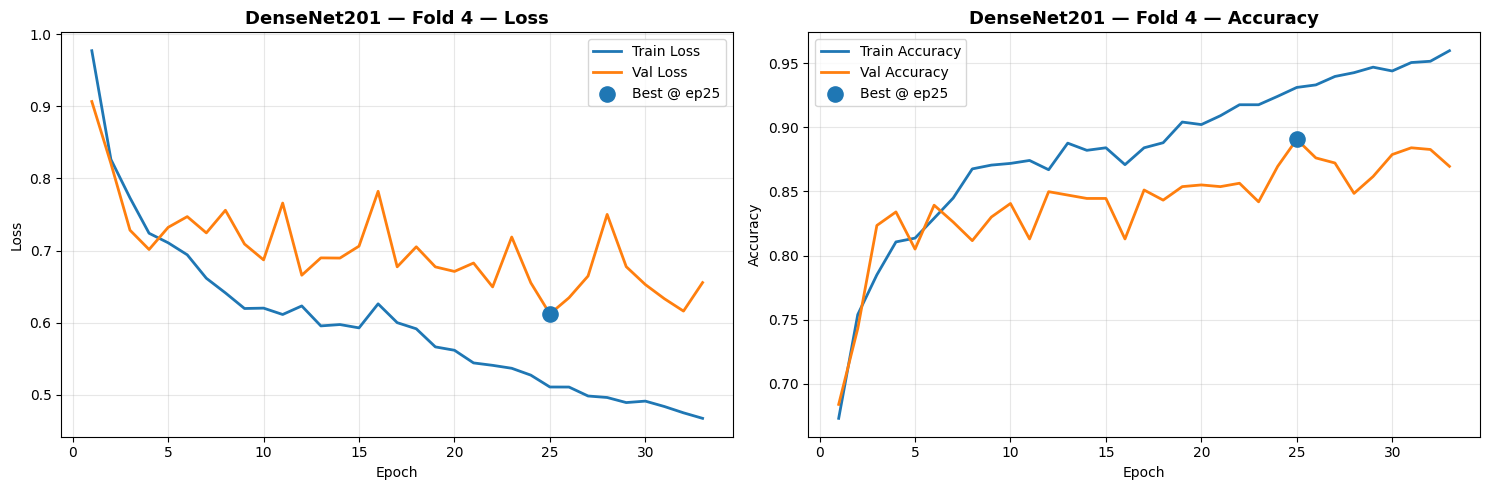

Best val loss 0.6120 @ epoch 25
Best val acc  0.8906  @ epoch 25

  FOLD 5 / 5
  Train: 3036  |  Val: 759
Found 3036 validated image filenames belonging to 4 classes.
Found 759 validated image filenames belonging to 4 classes.
  [Phase 1] Training head (backbone frozen) ...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.5816 - loss: 1.1502 - top2_acc: 0.7988 - val_accuracy: 0.6219 - val_loss: 1.0400 - val_top2_acc: 0.8406 - learning_rate: 3.3333e-04
Epoch 2/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 62s 650ms/step - accuracy: 0.7518 - loss: 0.8346 - top2_acc: 0.9313 - val_accuracy: 0.7536 - val_loss: 0.8400 - val_top2_acc: 0.9236 - learning_rate: 6.6667e-04
Epoch 3/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 60s 633ms/step - accuracy: 0.7876 - loss: 0.7647 - top2_acc: 0.9398 - val_accuracy: 0.7655 - val_loss: 0.8129 - val_top2_acc: 0.9420 - learning_rate: 0.0010
Epoch 4/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 60s 635ms/step - accuracy: 0.8258 - loss: 0.7068 - top2_acc: 0.9646 - val_accuracy: 0.6904 - val_loss: 0.9654 - val_top2_acc: 0.9262 - learning_rate: 0.0010
Epoch 5/15
95/95 ━━━━━━━━━━━━━━━━━━━━ 61s 641ms/step - accuracy: 0.8161 - loss: 0.6991 - top2_acc: 0.9614 - val_accuracy: 0.8076 - val_loss: 0.7926 - val_top2_acc: 0.9223 - learning_rate: 9.8313e-04
Epoch 6/15
95/9

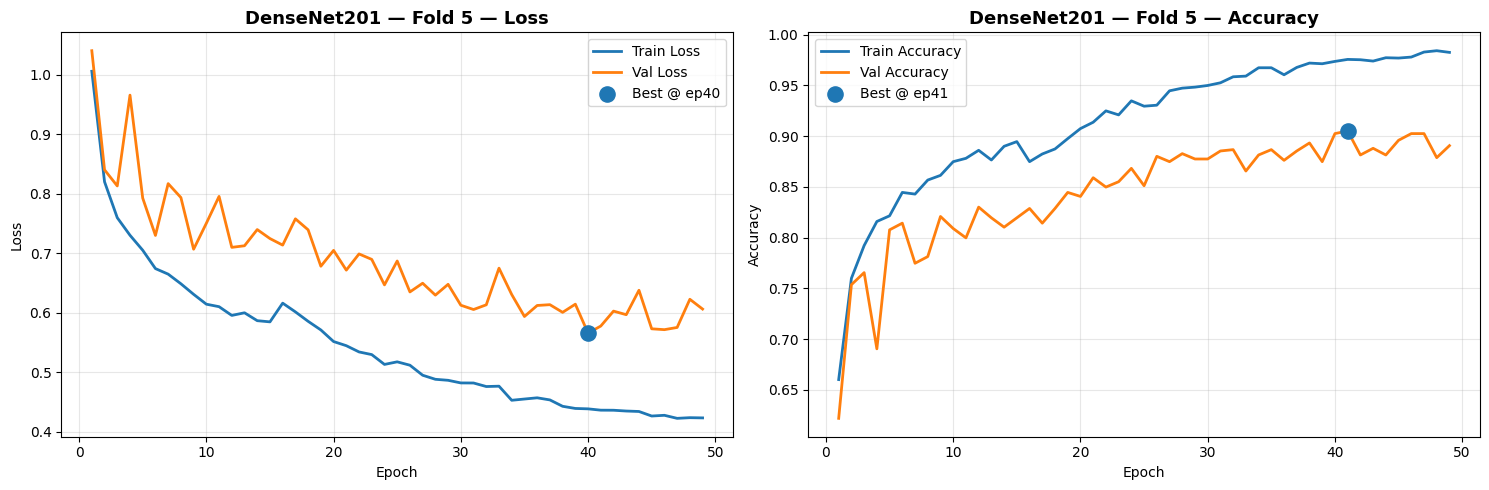

Best val loss 0.5659 @ epoch 40
Best val acc  0.9051  @ epoch 41

K-FOLD CROSS VALIDATION COMPLETE


In [8]:

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_metrics     = []    # list of dicts — one per fold
best_fold_val_acc = 0.0  # FIX: track best val_acc across folds
best_model        = None
best_val_gen      = None
fold_histories = []  # Keras History objects

X = train_val_df['filepaths'].values
y = train_val_df['labels'].values

for fold_no, (train_idx, val_idx) in enumerate(
        skf.split(X, y), start=1):

    print(f"\n{'='*70}")
    print(f"  FOLD {fold_no} / {N_FOLDS}")
    print(f"{'='*70}")

    fold_train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df   = train_val_df.iloc[val_idx  ].reset_index(drop=True)

    print(f"  Train: {len(fold_train_df)}  |  Val: {len(fold_val_df)}")

    # ── Generators ────────────────────────────────────────────────────────────
    train_gen = train_datagen.flow_from_dataframe(
        fold_train_df, x_col='filepaths', y_col='labels',
        target_size=IMG_SIZE, class_mode='categorical',
        color_mode='rgb', shuffle=True, batch_size=BATCH_SIZE
    )
    val_gen = val_datagen.flow_from_dataframe(
        fold_val_df, x_col='filepaths', y_col='labels',
        target_size=IMG_SIZE, class_mode='categorical',
        color_mode='rgb', shuffle=False, batch_size=BATCH_SIZE
    )

    # ── Build model (fresh for each fold) ─────────────────────────────────────
    # NOTE: clear_session() is called BEFORE build — backbone ref is valid
    keras.backend.clear_session()
    model, backbone = build_densenet201(num_classes, trainable_base=False)

    # ── Phase 1 — Train head only ──────────────────────────────────────────────
    model.compile(
        optimizer=AdamW(learning_rate=INIT_LR, weight_decay=WEIGHT_DECAY),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
        metrics=['accuracy',
                 keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_acc')]
    )

    # FIX: default args capture current values (avoids closure capture bug)
    _INIT_LR = INIT_LR
    lr_scheduler = LearningRateScheduler(
        lambda ep, lr, _ilr=_INIT_LR: cosine_annealing_with_warmup(
            ep, lr, warmup_epochs=3, total_epochs=15,
            eta_min=1e-5, eta_max=_ilr
        ), verbose=0
    )
    early_stop = EarlyStopping(
        monitor='val_accuracy', patience=PATIENCE,
        restore_best_weights=True, verbose=1
    )

    print("  [Phase 1] Training head (backbone frozen) ...")
    hist1 = model.fit(
        train_gen, validation_data=val_gen,
        epochs=15, callbacks=[lr_scheduler, early_stop], verbose=1
    )

    # ── Phase 2 — Fine-tune last N backbone layers ─────────────────────────────
    backbone.trainable = True
    for layer in backbone.layers[:UNFREEZE_FROM]:  # freeze all but last 50
        layer.trainable = False

    model.compile(
        optimizer=AdamW(learning_rate=FINETUNE_LR, weight_decay=WEIGHT_DECAY),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
        metrics=['accuracy',
                 keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_acc')]
    )

    _FT_LR = FINETUNE_LR
    _EPOCHS = EPOCHS
    lr_scheduler2 = LearningRateScheduler(
        lambda ep, lr, _ftlr=_FT_LR, _ep=_EPOCHS: cosine_annealing_with_warmup(
            ep, lr, warmup_epochs=2, total_epochs=_ep,
            eta_min=1e-6, eta_max=_ftlr
        ), verbose=0
    )
    early_stop2 = EarlyStopping(
        monitor='val_accuracy', patience=PATIENCE,
        restore_best_weights=True, verbose=1
    )
    ckpt = ModelCheckpoint(
        f'fold_{fold_no}_best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=0
    )

    print(f"  [Phase 2] Fine-tuning last {abs(UNFREEZE_FROM)} backbone layers ...")
    hist2 = model.fit(
        train_gen, validation_data=val_gen,
        epochs=EPOCHS, callbacks=[lr_scheduler2, early_stop2, ckpt], verbose=1
    )

    # ── Combine histories ──────────────────────────────────────────────────────
    class _CombinedHistory:
        def __init__(self, h1, h2):
            self.history = {}
            for k in h1.history:
                self.history[k] = h1.history[k] + h2.history[k]
    combined_hist = _CombinedHistory(hist1, hist2)
    fold_histories.append(combined_hist)

    # ── Validation evaluation ──────────────────────────────────────────────────
    val_gen.reset()
    val_pred_prob = model.predict(val_gen, verbose=0)
    val_pred      = np.argmax(val_pred_prob, axis=1)
    val_true      = val_gen.classes

    fold_acc  = accuracy_score(val_true, val_pred)
    fold_f1   = f1_score(val_true, val_pred, average='macro', zero_division=0)
    fold_prec = precision_score(val_true, val_pred, average='macro', zero_division=0)
    fold_rec  = recall_score(val_true, val_pred, average='macro', zero_division=0)

    fold_metrics.append({
        'fold'     : fold_no,
        'accuracy' : round(fold_acc,  4),
        'f1_macro' : round(fold_f1,   4),
        'precision': round(fold_prec, 4),
        'recall'   : round(fold_rec,  4),
        'best_val_acc': round(max(combined_hist.history['val_accuracy']), 4)
    })

    print(f"\n  Fold {fold_no} Results:")
    print(f"    Accuracy  : {fold_acc:.4f}")
    print(f"    F1 Macro  : {fold_f1:.4f}")
    print(f"    Precision : {fold_prec:.4f}")
    print(f"    Recall    : {fold_rec:.4f}")

    # Plot per-fold history
    plot_history(combined_hist, title=f'DenseNet201 — Fold {fold_no}')

    # FIX: track the fold with highest val_accuracy as the best model
    current_best_val = max(combined_hist.history['val_accuracy'])
    if fold_no == 1 or current_best_val > best_fold_val_acc:
        best_fold_val_acc = current_best_val
        best_model        = model
        best_val_gen      = val_gen
        print(f"  ★ New best model (fold {fold_no}) — val_acc={current_best_val:.4f}")

print("\n" + "="*70)
print("K-FOLD CROSS VALIDATION COMPLETE")
print("="*70)


K-FOLD CROSS-VALIDATION SUMMARY
      accuracy  f1_macro  precision  recall  best_val_acc
fold                                                     
1       0.8867    0.8875     0.9006  0.8857        0.8867
2       0.9117    0.9117     0.9179  0.9108        0.9117
3       0.9051    0.9058     0.9128  0.9044        0.9051
4       0.8906    0.8918     0.9005  0.8897        0.8906
5       0.9051    0.9046     0.9120  0.9033        0.9051
----------------------------------------------------------------------
MEAN ±  STD:
  accuracy    : 0.8998 ± 0.0107
  f1_macro    : 0.9003 ± 0.0102
  precision   : 0.9088 ± 0.0078
  recall      : 0.8988 ± 0.0106


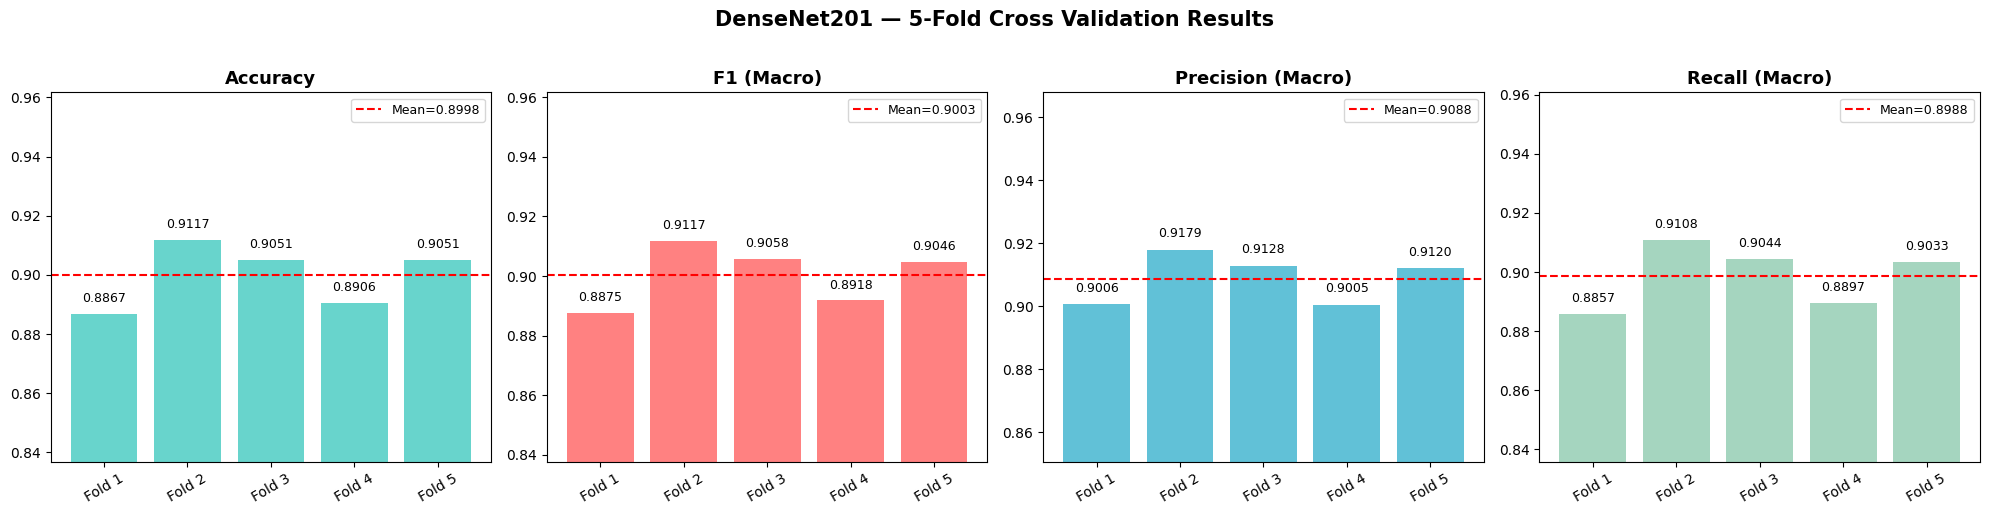

In [9]:

kfold_df = pd.DataFrame(fold_metrics).set_index('fold')
print("\n" + "="*70)
print("K-FOLD CROSS-VALIDATION SUMMARY")
print("="*70)
print(kfold_df.to_string())
print("-"*70)
print("MEAN ±  STD:")
for col in ['accuracy', 'f1_macro', 'precision', 'recall']:
    mean = kfold_df[col].mean()
    std  = kfold_df[col].std()
    print(f"  {col:<12}: {mean:.4f} ± {std:.4f}")
print("="*70)

# ─── Visual summary ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics   = ['accuracy', 'f1_macro', 'precision', 'recall']
titles    = ['Accuracy', 'F1 (Macro)', 'Precision (Macro)', 'Recall (Macro)']
colors    = ['#4ECDC4', '#FF6B6B', '#45B7D1', '#96CEB4']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    vals = kfold_df[metric].values
    ax.bar([f'Fold {i+1}' for i in range(N_FOLDS)], vals, color=color, alpha=0.85)
    ax.axhline(vals.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean={vals.mean():.4f}')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylim(max(0, vals.min() - 0.05), min(1, vals.max() + 0.05))
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    for j, v in enumerate(vals):
        ax.text(j, v + 0.003, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('DenseNet201 — 5-Fold Cross Validation Results',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Found 422 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


14/14 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.9144 - loss: 0.5463 - top2_acc: 0.9804

Test Loss     : 0.5518
Test Accuracy : 0.9147
Test Top-2 Acc: 0.9763


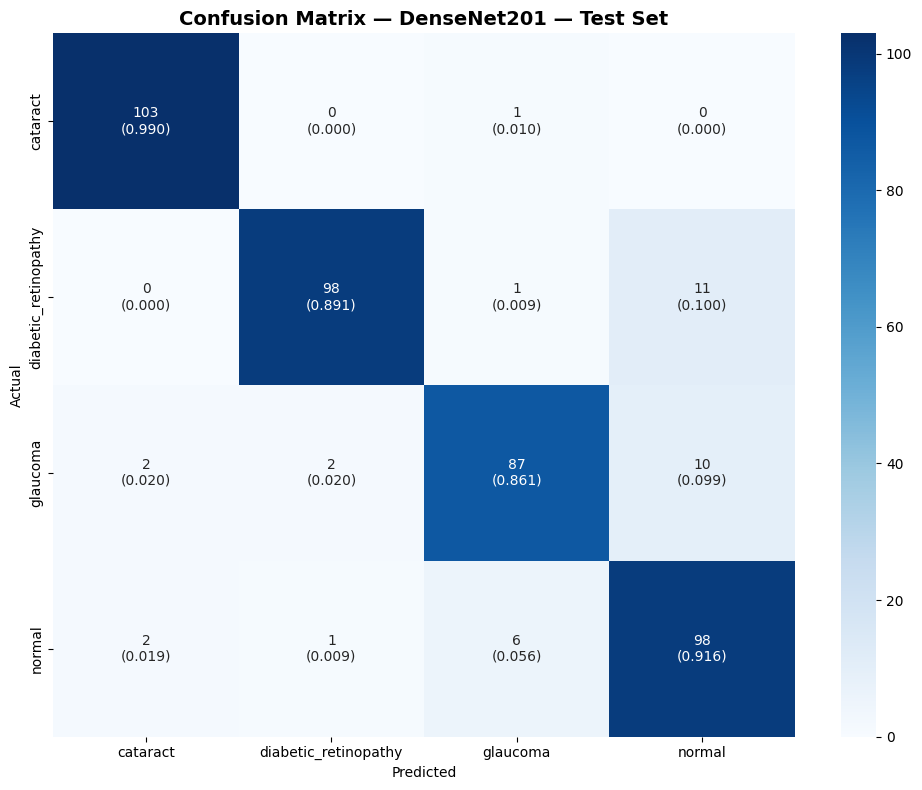


CLASSIFICATION REPORT — DenseNet201 — Test Set
Class                 Precision     Recall   F1-Score    Support
--------------------------------------------------------------------------------
cataract                 0.9626     0.9904     0.9763        104
diabetic_retinopathy     0.9703     0.8909     0.9289        110
glaucoma                 0.9158     0.8614     0.8878        101
normal                   0.8235     0.9159     0.8673        107
--------------------------------------------------------------------------------
macro avg                0.9181     0.9146     0.9151        422
weighted avg             0.9181     0.9147     0.9151        422

Overall Accuracy: 0.9147
Mean Average Precision (mAP): 0.9679


In [10]:
# ─── Test-set evaluation ─────────────────────────────────────────────────────
# Use the model saved from the best fold checkpoint if desired;
# here we re-use the last fold's best model for simplicity.
test_gen = val_datagen.flow_from_dataframe(
    test_df, x_col='filepaths', y_col='labels',
    target_size=IMG_SIZE, class_mode='categorical',
    color_mode='rgb', shuffle=False, batch_size=BATCH_SIZE
)

test_gen.reset()
test_loss, test_acc, test_top2 = best_model.evaluate(test_gen, verbose=1)

test_gen.reset()
y_pred_prob = best_model.predict(test_gen, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = test_gen.classes

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Top-2 Acc: {test_top2:.4f}")

# ── Confusion matrix
plot_confusion_matrix(y_true, y_pred, class_names, title='DenseNet201 — Test Set')

# ── Full report
report = print_report(y_true, y_pred, class_names, model_name='DenseNet201 — Test Set')

# ── Mean AP
y_true_oh = keras.utils.to_categorical(y_true, num_classes)
mean_ap   = np.mean([average_precision_score(y_true_oh[:, i], y_pred_prob[:, i])
                     for i in range(num_classes)])
print(f"Mean Average Precision (mAP): {mean_ap:.4f}")

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# COMPREHENSIVE VISUALISATION SUITE — DenseNet201 Eye Disease Classifier
# Plots: Confusion Matrix (normalised + raw) | Per-class Metrics Bar Chart |
#        ROC Curves (per-class + macro) | Precision-Recall Curves |
#        Confidence Distribution | Confidence Intervals (bootstrap) |
#        Prediction Confidence Heatmap | K-Fold Radar Chart |
#        Calibration Curve | Error Analysis | Top Misclassifications
# ═══════════════════════════════════════════════════════════════════════════

from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ─── Colour palette (consistent across all plots) ───────────────────────────
PALETTE   = ['#4ECDC4', '#FF6B6B', '#45B7D1', '#96CEB4',
             '#FECA57', '#FF9FF3', '#54A0FF', '#5F27CD']
CLASS_COLORS = {cn: PALETTE[i % len(PALETTE)] for i, cn in enumerate(class_names)}

# ════════════════════════════════════════════════════════════════════════════
# 1. DUAL CONFUSION MATRIX (Raw counts  +  Row-normalised proportions)
# ════════════════════════════════════════════════════════════════════════════
def plot_dual_confusion_matrix(y_true, y_pred, class_names, title='DenseNet201'):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    for ax, data, fmt, t in zip(
            axes,
            [cm,      cm_norm],
            ['d',     '.3f'],
            ['Raw Counts', 'Row-Normalised (Recall per class)']):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    linewidths=0.5, linecolor='white',
                    cbar_kws={'shrink': 0.8}, ax=ax)
        ax.set_title(f'{title}\n{t}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Predicted Label', fontsize=11)
        ax.set_ylabel('True Label',      fontsize=11)
        ax.tick_params(axis='x', rotation=30)
        ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.show()
    return cm

# ════════════════════════════════════════════════════════════════════════════
# 2. PER-CLASS METRIC BAR CHART (Precision / Recall / F1 / Support)
# ════════════════════════════════════════════════════════════════════════════
def plot_per_class_metrics(y_true, y_pred, class_names, title='DenseNet201'):
    report = classification_report(y_true, y_pred, target_names=class_names,
                                   digits=4, output_dict=True)

    metrics  = ['precision', 'recall', 'f1-score']
    x        = np.arange(len(class_names))
    width    = 0.25
    colors   = ['#4ECDC4', '#FF6B6B', '#45B7D1']

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Left: grouped bar per class
    for j, (metric, color) in enumerate(zip(metrics, colors)):
        vals = [report[cn][metric] for cn in class_names]
        axes[0].bar(x + j * width, vals, width, label=metric.capitalize(),
                    color=color, alpha=0.87, edgecolor='white')

    axes[0].set_xticks(x + width)
    axes[0].set_xticklabels(class_names, rotation=25, ha='right')
    axes[0].set_ylim(0, 1.1)
    axes[0].set_ylabel('Score')
    axes[0].set_title(f'{title} — Per-Class Metrics', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].axhline(0.9, color='grey', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].grid(axis='y', alpha=0.3)

    # Add value labels
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.3f', fontsize=8, padding=2)

    # Right: support (sample count per class)
    supports = [int(report[cn]['support']) for cn in class_names]
    bars = axes[1].bar(class_names, supports,
                        color=[CLASS_COLORS[cn] for cn in class_names],
                        alpha=0.85, edgecolor='white')
    axes[1].set_title(f'{title} — Class Support (Sample Count)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Number of Samples')
    axes[1].tick_params(axis='x', rotation=25)
    axes[1].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, supports):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()
    return report

# ════════════════════════════════════════════════════════════════════════════
# 3. ROC CURVES — per class + macro average
# ════════════════════════════════════════════════════════════════════════════
def plot_roc_curves(y_true, y_pred_prob, class_names, title='DenseNet201'):
    n_classes = len(class_names)
    y_true_oh = label_binarize(y_true, classes=list(range(n_classes)))

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_oh[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Macro average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Left: individual class ROC
    for i, cn in enumerate(class_names):
        axes[0].plot(fpr[i], tpr[i],
                     color=PALETTE[i % len(PALETTE)], linewidth=2.5,
                     label=f'{cn}  (AUC = {roc_auc[i]:.4f})')
    axes[0].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random')
    axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])
    axes[0].set_xlabel('False Positive Rate', fontsize=11)
    axes[0].set_ylabel('True Positive Rate',  fontsize=11)
    axes[0].set_title(f'{title} — ROC Curves (Per Class)', fontsize=13, fontweight='bold')
    axes[0].legend(loc='lower right', fontsize=10)
    axes[0].grid(alpha=0.3)

    # Right: macro-average ROC
    axes[1].plot(all_fpr, mean_tpr, color='#FF6B6B', linewidth=3,
                 label=f'Macro-avg ROC (AUC = {macro_auc:.4f})')
    for i, cn in enumerate(class_names):
        axes[1].plot(fpr[i], tpr[i], color=PALETTE[i % len(PALETTE)],
                     linewidth=1, alpha=0.4, linestyle='--')
    axes[1].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5)
    axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])
    axes[1].set_xlabel('False Positive Rate', fontsize=11)
    axes[1].set_ylabel('True Positive Rate',  fontsize=11)
    axes[1].set_title(f'{title} — Macro-Average ROC', fontsize=13, fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=11)
    axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()
    print(f"Macro-Average AUC: {macro_auc:.4f}")
    return roc_auc, macro_auc

# ════════════════════════════════════════════════════════════════════════════
# 4. PRECISION-RECALL CURVES — per class + mean AP summary
# ════════════════════════════════════════════════════════════════════════════
def plot_precision_recall_curves(y_true, y_pred_prob, class_names, title='DenseNet201'):
    n_classes = len(class_names)
    y_true_oh = label_binarize(y_true, classes=list(range(n_classes)))

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    ap_scores = []
    for i, cn in enumerate(class_names):
        prec, rec, _ = precision_recall_curve(y_true_oh[:, i], y_pred_prob[:, i])
        ap = average_precision_score(y_true_oh[:, i], y_pred_prob[:, i])
        ap_scores.append(ap)
        axes[0].plot(rec, prec, color=PALETTE[i % len(PALETTE)],
                     linewidth=2.5, label=f'{cn}  (AP = {ap:.4f})')

    baseline = y_true_oh.sum(axis=0).mean() / len(y_true)
    axes[0].axhline(baseline, color='grey', linestyle='--', linewidth=1,
                    label=f'Baseline ({baseline:.3f})')
    axes[0].set_xlabel('Recall',    fontsize=11)
    axes[0].set_ylabel('Precision', fontsize=11)
    axes[0].set_title(f'{title} — Precision-Recall Curves', fontsize=13, fontweight='bold')
    axes[0].legend(loc='upper right', fontsize=10)
    axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.05])
    axes[0].grid(alpha=0.3)

    # Right: AP bar chart
    bars = axes[1].bar(class_names, ap_scores,
                        color=[PALETTE[i % len(PALETTE)] for i in range(n_classes)],
                        alpha=0.85, edgecolor='white')
    axes[1].axhline(np.mean(ap_scores), color='red', linestyle='--', linewidth=2,
                    label=f'mAP = {np.mean(ap_scores):.4f}')
    axes[1].set_ylim(0, 1.1)
    axes[1].set_title(f'{title} — Average Precision per Class', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Average Precision')
    axes[1].tick_params(axis='x', rotation=25)
    axes[1].legend(fontsize=11)
    axes[1].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, ap_scores):
        axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout(); plt.show()
    print(f"Mean Average Precision (mAP): {np.mean(ap_scores):.4f}")
    return ap_scores

# ════════════════════════════════════════════════════════════════════════════
# 5. CONFIDENCE DISTRIBUTION (correct vs incorrect predictions)
# ════════════════════════════════════════════════════════════════════════════

       
def plot_confidence_distribution(y_true, y_pred, y_pred_prob, class_names,
                                  title='DenseNet201'):

    import numpy as np
    import matplotlib.pyplot as plt

    # ✅ CRITICAL FIX: ensure numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred_prob = np.array(y_pred_prob)

    max_conf = np.max(y_pred_prob, axis=1)
    correct  = (y_pred == y_true)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Left: overall histogram
    axes[0].hist(max_conf[correct], bins=30, alpha=0.7,
                 label=f'Correct  (n={np.sum(correct)})', density=True)
    axes[0].hist(max_conf[~correct], bins=30, alpha=0.7,
                 label=f'Incorrect (n={np.sum(~correct)})', density=True)

    axes[0].set_xlabel('Predicted Confidence', fontsize=11)
    axes[0].set_ylabel('Density', fontsize=11)
    axes[0].set_title(f'{title}\nConfidence Distribution', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(alpha=0.3)

    # Middle: per-class mean confidence
    mean_conf_class = []
    for i, cn in enumerate(class_names):
        mask = (y_true == i)

        if np.sum(mask) > 0:
            mean_conf_class.append(np.mean(max_conf[mask]))
        else:
            mean_conf_class.append(0)

    bars = axes[1].bar(class_names, mean_conf_class,
                        color=[PALETTE[i % len(PALETTE)] for i in range(len(class_names))],
                        alpha=0.85, edgecolor='white')

    axes[1].set_ylim(0, 1.1)
    axes[1].set_title(f'{title}\nMean Confidence per Class', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Mean Confidence')
    axes[1].tick_params(axis='x', rotation=25)
    axes[1].grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, mean_conf_class):
        axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=10)

    # Right: confidence box-plot per class
    data_per_class = []
    for i in range(len(class_names)):
        mask = (y_true == i)
        data_per_class.append(max_conf[mask] if np.sum(mask) > 0 else np.array([0]))

    bp = axes[2].boxplot(data_per_class, labels=class_names,
                          patch_artist=True, notch=True)

    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[2].set_title(f'{title}\nConfidence Box-Plot per Class', fontsize=13, fontweight='bold')
    axes[2].set_ylabel('Predicted Confidence')
    axes[2].tick_params(axis='x', rotation=25)
    axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 6. BOOTSTRAP CONFIDENCE INTERVALS for Accuracy / F1 / Precision / Recall
# ════════════════════════════════════════════════════════════════════════════
def bootstrap_confidence_intervals(y_true, y_pred, class_names,
                                    n_bootstrap=1000, ci=0.95,
                                    title='DenseNet201'):
    rng  = np.random.default_rng(42)
    n    = len(y_true)
    half = (1 - ci) / 2

    metric_fns = {
        'Accuracy' : lambda yt, yp: accuracy_score(yt, yp),
        'F1 Macro' : lambda yt, yp: f1_score(yt, yp, average='macro', zero_division=0),
        'Precision': lambda yt, yp: precision_score(yt, yp, average='macro', zero_division=0),
        'Recall'   : lambda yt, yp: recall_score(yt, yp, average='macro', zero_division=0),
    }

    results = {}
    for name, fn in metric_fns.items():
        boot_scores = []
        for _ in range(n_bootstrap):
            idx  = rng.integers(0, n, size=n)
            boot_scores.append(fn(y_true[idx], y_pred[idx]))
        observed = fn(y_true, y_pred)
        lo = np.quantile(boot_scores, half)
        hi = np.quantile(boot_scores, 1 - half)
        results[name] = {'observed': observed, 'lo': lo, 'hi': hi,
                         'boot_scores': boot_scores}

    # ── Plot 1: CI error bar chart ──────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    names  = list(results.keys())
    obs    = [results[n]['observed'] for n in names]
    lo_err = [results[n]['observed'] - results[n]['lo'] for n in names]
    hi_err = [results[n]['hi'] - results[n]['observed'] for n in names]

    bars = axes[0].bar(names, obs,
                        color=['#4ECDC4','#FF6B6B','#45B7D1','#96CEB4'],
                        alpha=0.85, edgecolor='white', zorder=3)
    axes[0].errorbar(names, obs,
                     yerr=[lo_err, hi_err],
                     fmt='none', color='black', capsize=8, capthick=2,
                     linewidth=2, zorder=4)
    axes[0].set_ylim(max(0, min(obs) - 0.15), min(1, max(obs) + 0.10))
    axes[0].set_title(f'{title}\nBootstrap {int(ci*100)}% Confidence Intervals\n(n_bootstrap={n_bootstrap})',
                       fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Score')
    axes[0].grid(axis='y', alpha=0.3, zorder=0)
    for bar, o, lo, hi in zip(bars, obs,
                                [results[n]['lo'] for n in names],
                                [results[n]['hi'] for n in names]):
        axes[0].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height() + hi_err[list(obs).index(o)] + 0.005,
                     f'{o:.4f}\n[{lo:.4f}, {hi:.4f}]',
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

    # ── Plot 2: Bootstrap distribution histograms ───────────────────────────
    colors2 = ['#4ECDC4','#FF6B6B','#45B7D1','#96CEB4']
    for idx, (name, color) in enumerate(zip(names, colors2)):
        axes[1].hist(results[name]['boot_scores'], bins=40, alpha=0.6,
                     color=color, label=name, density=True)
        lo_v = results[name]['lo']; hi_v = results[name]['hi']
        axes[1].axvline(lo_v, color=color, linestyle='--', linewidth=1.5)
        axes[1].axvline(hi_v, color=color, linestyle='--', linewidth=1.5)

    axes[1].set_xlabel('Metric Score',  fontsize=11)
    axes[1].set_ylabel('Density',       fontsize=11)
    axes[1].set_title(f'{title}\nBootstrap Sampling Distributions',
                       fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()

    # Print table
    print(f"\n{'='*70}")
    print(f"BOOTSTRAP {int(ci*100)}% CONFIDENCE INTERVALS — {title}")
    print(f"{'='*70}")
    print(f"{'Metric':<14} {'Observed':>10} {'Lower CI':>10} {'Upper CI':>10} {'CI Width':>10}")
    print("-"*70)
    for name in names:
        r = results[name]
        print(f"{name:<14} {r['observed']:>10.4f} {r['lo']:>10.4f} {r['hi']:>10.4f} {r['hi']-r['lo']:>10.4f}")
    print("="*70)
    return results

# ════════════════════════════════════════════════════════════════════════════
# 7. CALIBRATION CURVE (Reliability Diagram)
# ════════════════════════════════════════════════════════════════════════════
def plot_calibration_curve(y_true, y_pred_prob, class_names, n_bins=10,
                            title='DenseNet201'):
    n_classes = len(class_names)
    y_true_oh = label_binarize(y_true, classes=list(range(n_classes)))

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    ece_scores = []
    for i, cn in enumerate(class_names):
        prob_true  = y_true_oh[:, i]
        prob_pred  = y_pred_prob[:, i]
        bins       = np.linspace(0, 1, n_bins + 1)
        bin_ids    = np.digitize(prob_pred, bins[1:-1])
        bin_acc, bin_conf, bin_cnt = [], [], []

        for b in range(n_bins):
            mask = bin_ids == b
            if mask.sum() == 0:
                continue
            bin_acc.append(prob_true[mask].mean())
            bin_conf.append(prob_pred[mask].mean())
            bin_cnt.append(mask.sum())

        ece = np.sum([cnt * abs(a - c)
                      for a, c, cnt in zip(bin_acc, bin_conf, bin_cnt)]) / len(y_true)
        ece_scores.append(ece)

        axes[0].plot(bin_conf, bin_acc, 'o-', color=PALETTE[i%len(PALETTE)],
                     linewidth=2, markersize=7,
                     label=f'{cn}  (ECE={ece:.4f})')

    axes[0].plot([0,1],[0,1],'k--', linewidth=1.5, label='Perfect calibration')
    axes[0].fill_between([0,1],[0,1],[0,1], alpha=0.05, color='grey')
    axes[0].set_xlabel('Mean Predicted Probability', fontsize=11)
    axes[0].set_ylabel('Fraction of Positives',      fontsize=11)
    axes[0].set_title(f'{title} — Reliability Diagram (Calibration)',
                       fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
    axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1])

    # Right: ECE bar
    bars = axes[1].bar(class_names, ece_scores,
                        color=[PALETTE[i%len(PALETTE)] for i in range(n_classes)],
                        alpha=0.85, edgecolor='white')
    axes[1].axhline(np.mean(ece_scores), color='red', linestyle='--', linewidth=2,
                    label=f'Mean ECE = {np.mean(ece_scores):.4f}')
    axes[1].set_title(f'{title} — Expected Calibration Error per Class',
                       fontsize=13, fontweight='bold')
    axes[1].set_ylabel('ECE (lower is better)')
    axes[1].tick_params(axis='x', rotation=25)
    axes[1].legend(fontsize=11); axes[1].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, ece_scores):
        axes[1].text(bar.get_x()+bar.get_width()/2, val+0.001,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout(); plt.show()
    print(f"Mean Expected Calibration Error: {np.mean(ece_scores):.4f}")
    return ece_scores

# ════════════════════════════════════════════════════════════════════════════
# 8. K-FOLD RADAR CHART
# ════════════════════════════════════════════════════════════════════════════
def plot_kfold_radar(fold_metrics_list, title='DenseNet201'):
    metrics_keys = ['accuracy', 'f1_macro', 'precision', 'recall']
    labels       = ['Accuracy', 'F1 Macro', 'Precision', 'Recall']
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]   # close the polygon

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for fold_data in fold_metrics_list:
        values = [fold_data[k] for k in metrics_keys]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2,
                label=f"Fold {fold_data['fold']}")
        ax.fill(angles, values, alpha=0.07)

    # Mean polygon
    mean_vals = [np.mean([fd[k] for fd in fold_metrics_list]) for k in metrics_keys]
    mean_vals += mean_vals[:1]
    ax.plot(angles, mean_vals, 'k-', linewidth=3, label='Mean', zorder=5)
    ax.fill(angles, mean_vals, alpha=0.12, color='black')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=12, fontweight='bold')
    ax.set_ylim(max(0, min(mean_vals[:-1]) - 0.1), 1.0)
    ax.set_title(f'{title} — K-Fold Radar Chart', fontsize=14,
                  fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
    ax.grid(True)
    plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 9. TOP MISCLASSIFIED SAMPLES
# ════════════════════════════════════════════════════════════════════════════
def plot_top_misclassifications(y_true, y_pred, y_pred_prob, test_gen,
                                 class_names, n=12, title='DenseNet201'):
    max_conf      = np.max(y_pred_prob, axis=1)
    wrong_mask    = (y_pred != y_true)
    wrong_indices = np.where(wrong_mask)[0]

    if len(wrong_indices) == 0:
        print("No misclassifications found — perfect test accuracy!"); return

    # Sort by confidence (most confidently wrong first)
    wrong_conf    = max_conf[wrong_indices]
    sorted_idx    = wrong_indices[np.argsort(-wrong_conf)][:n]

    test_gen.reset()
    all_images = []
    for imgs, _ in test_gen:
        all_images.extend(imgs)
        if len(all_images) >= len(y_true):
            break
    all_images = np.array(all_images[:len(y_true)])

    n_show = min(n, len(sorted_idx))
    cols   = 4
    rows   = math.ceil(n_show / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()
    fig.suptitle(f'{title} — Top {n_show} Most Confident Misclassifications',
                  fontsize=14, fontweight='bold', y=1.01)

    for idx_plot, sample_idx in enumerate(sorted_idx):
        ax  = axes[idx_plot]
        img = all_images[sample_idx]
        true_cls = class_names[y_true[sample_idx]]
        pred_cls = class_names[y_pred[sample_idx]]
        conf     = max_conf[sample_idx]

        ax.imshow(img)
        ax.set_title(f'True:  {true_cls}\nPred: {pred_cls}\nConf: {conf:.3f}',
                      fontsize=9, color='red')
        ax.axis('off')

    for i in range(n_show, len(axes)):
        axes[i].axis('off')

    plt.tight_layout(); plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 10. PREDICTION CONFIDENCE HEATMAP (class vs predicted class)
# ════════════════════════════════════════════════════════════════════════════
def plot_confidence_heatmap(y_true, y_pred_prob, class_names, title='DenseNet201'):
    n_classes = len(class_names)
    heatmap   = np.zeros((n_classes, n_classes))

    for i in range(n_classes):
        mask = (y_true == i)
        if mask.sum() > 0:
            heatmap[i] = y_pred_prob[mask].mean(axis=0)

    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Mean Predicted Probability'})
    plt.title(f'{title} — Mean Confidence Heatmap\n(True class rows → predicted class cols)',
               fontsize=13, fontweight='bold')
    plt.xlabel('Predicted Class'); plt.ylabel('True Class')
    plt.tick_params(axis='x', rotation=30)
    plt.tick_params(axis='y', rotation=0)
    plt.tight_layout(); plt.show()

print("All visualisation functions defined ✔")


All visualisation functions defined ✔



══════════════════════════════════════════════════════════════════════
1. DUAL CONFUSION MATRIX
══════════════════════════════════════════════════════════════════════


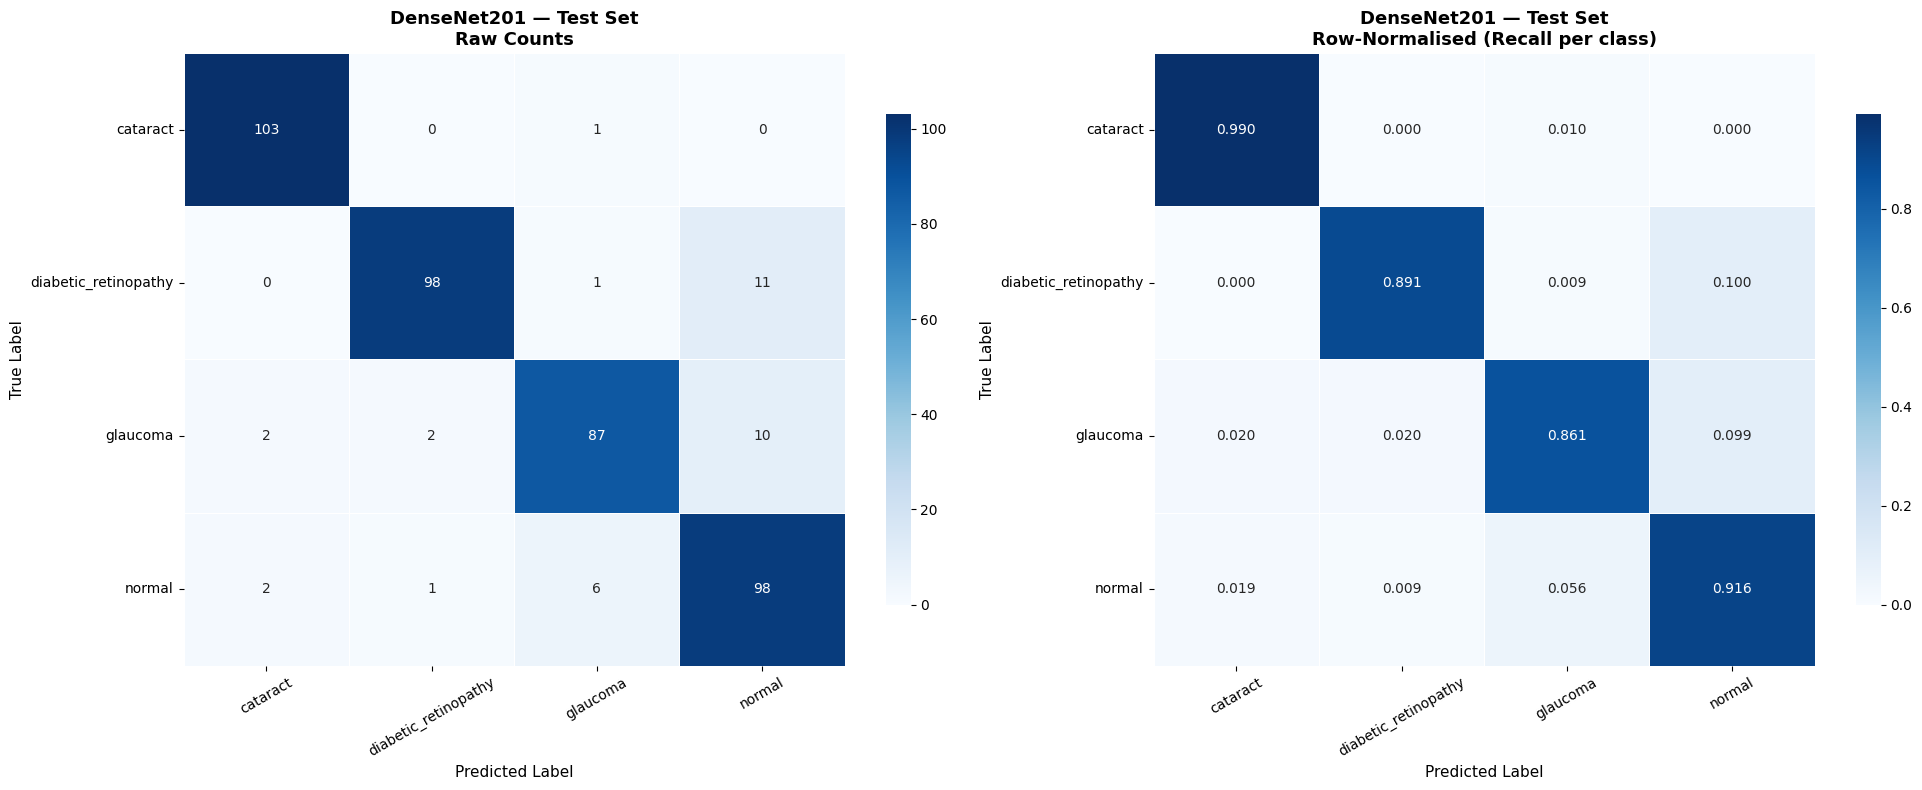


══════════════════════════════════════════════════════════════════════
2. PER-CLASS METRICS BAR CHART
══════════════════════════════════════════════════════════════════════


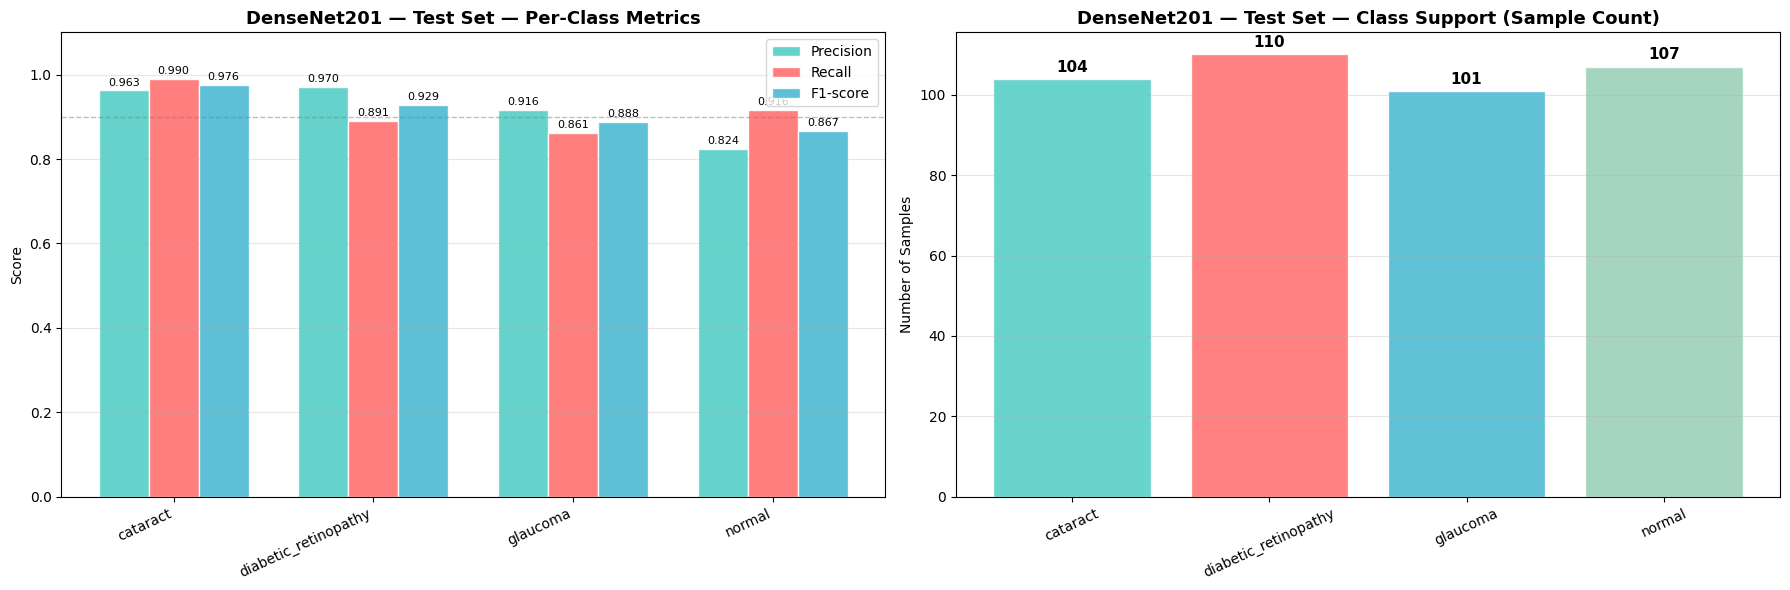


══════════════════════════════════════════════════════════════════════
3. ROC CURVES
══════════════════════════════════════════════════════════════════════


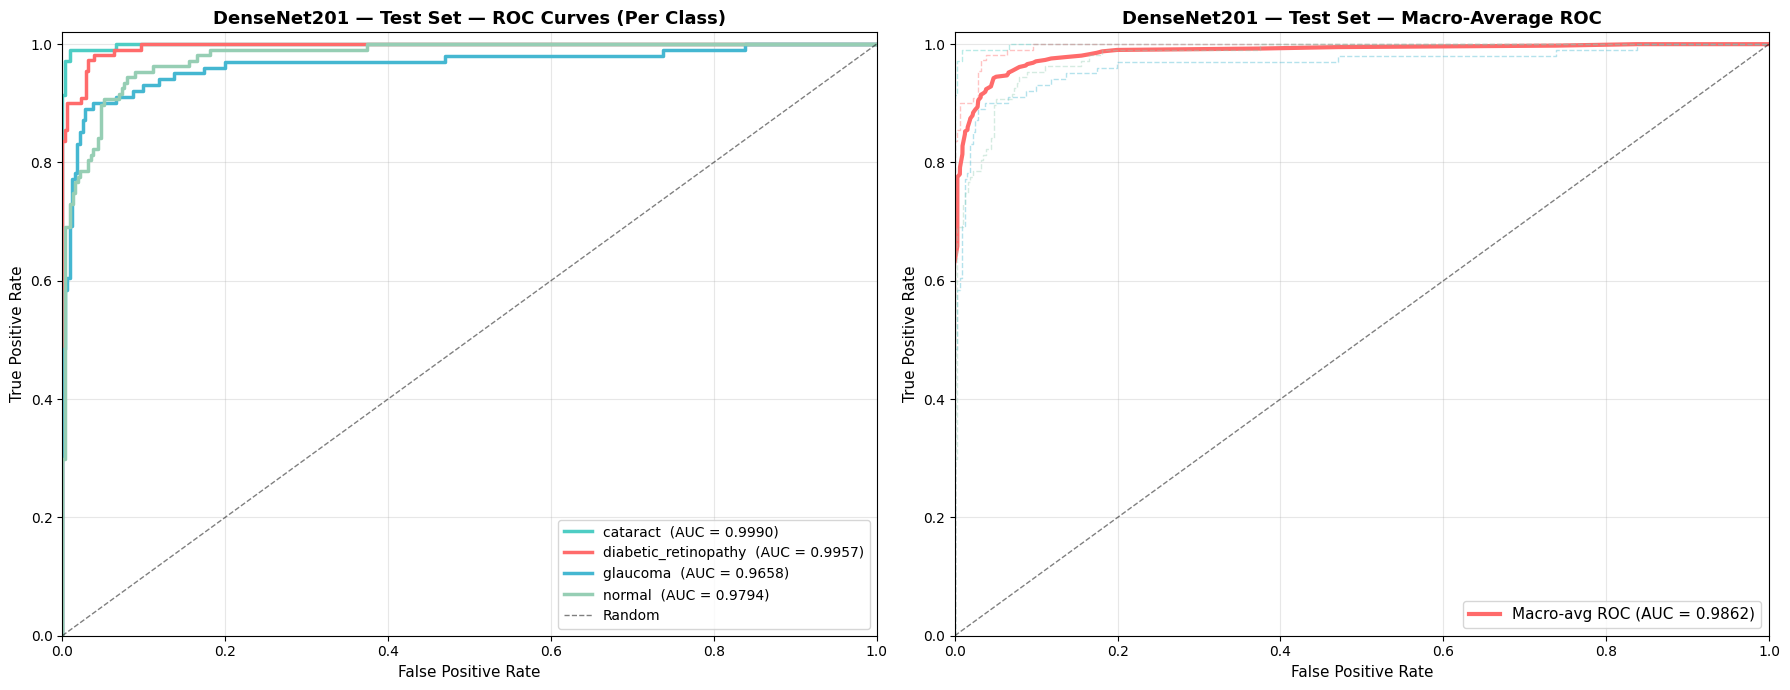

Macro-Average AUC: 0.9862

══════════════════════════════════════════════════════════════════════
4. PRECISION-RECALL CURVES
══════════════════════════════════════════════════════════════════════


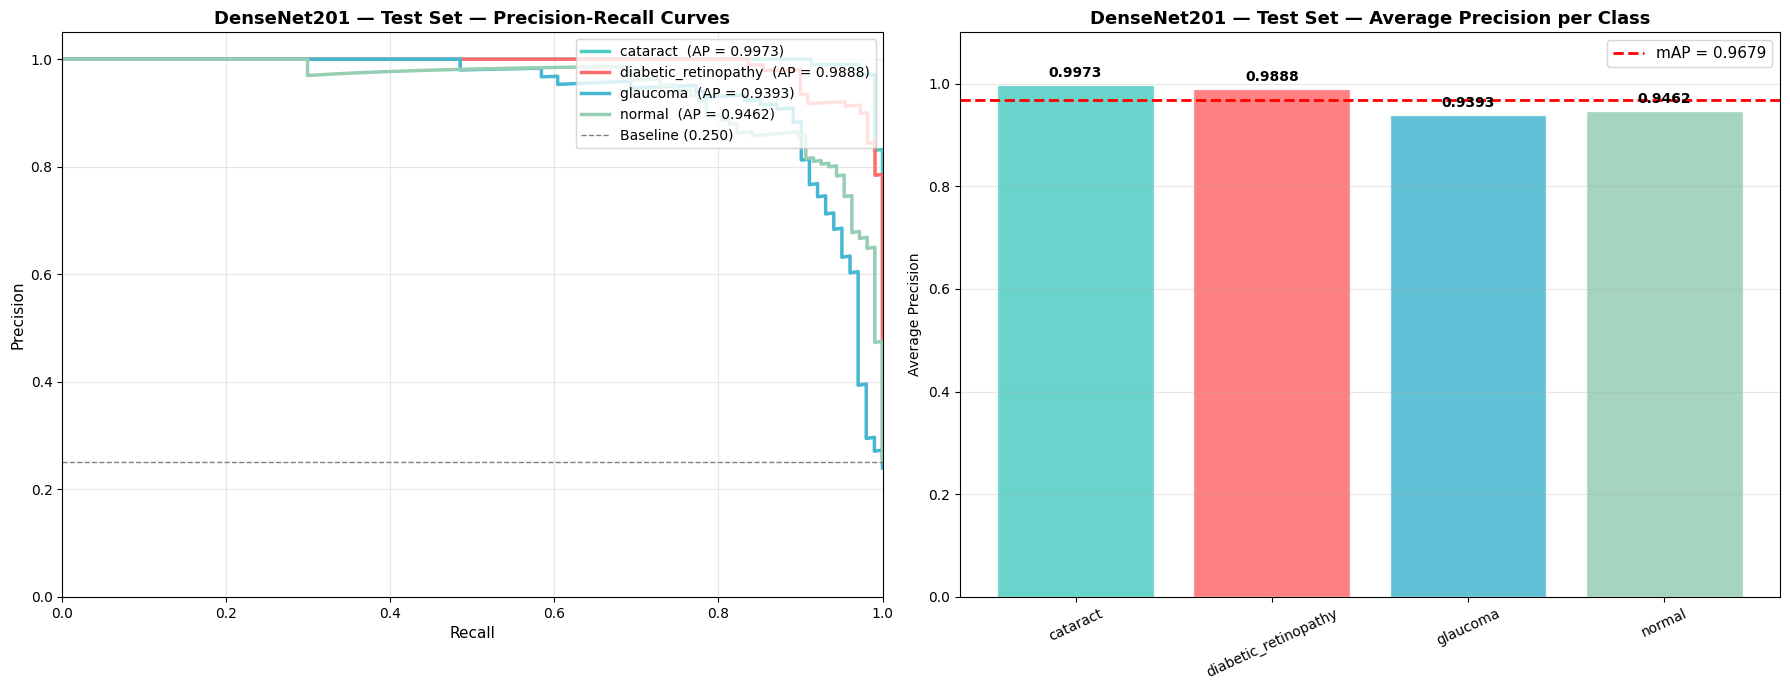

Mean Average Precision (mAP): 0.9679

══════════════════════════════════════════════════════════════════════
5. CONFIDENCE DISTRIBUTION
══════════════════════════════════════════════════════════════════════


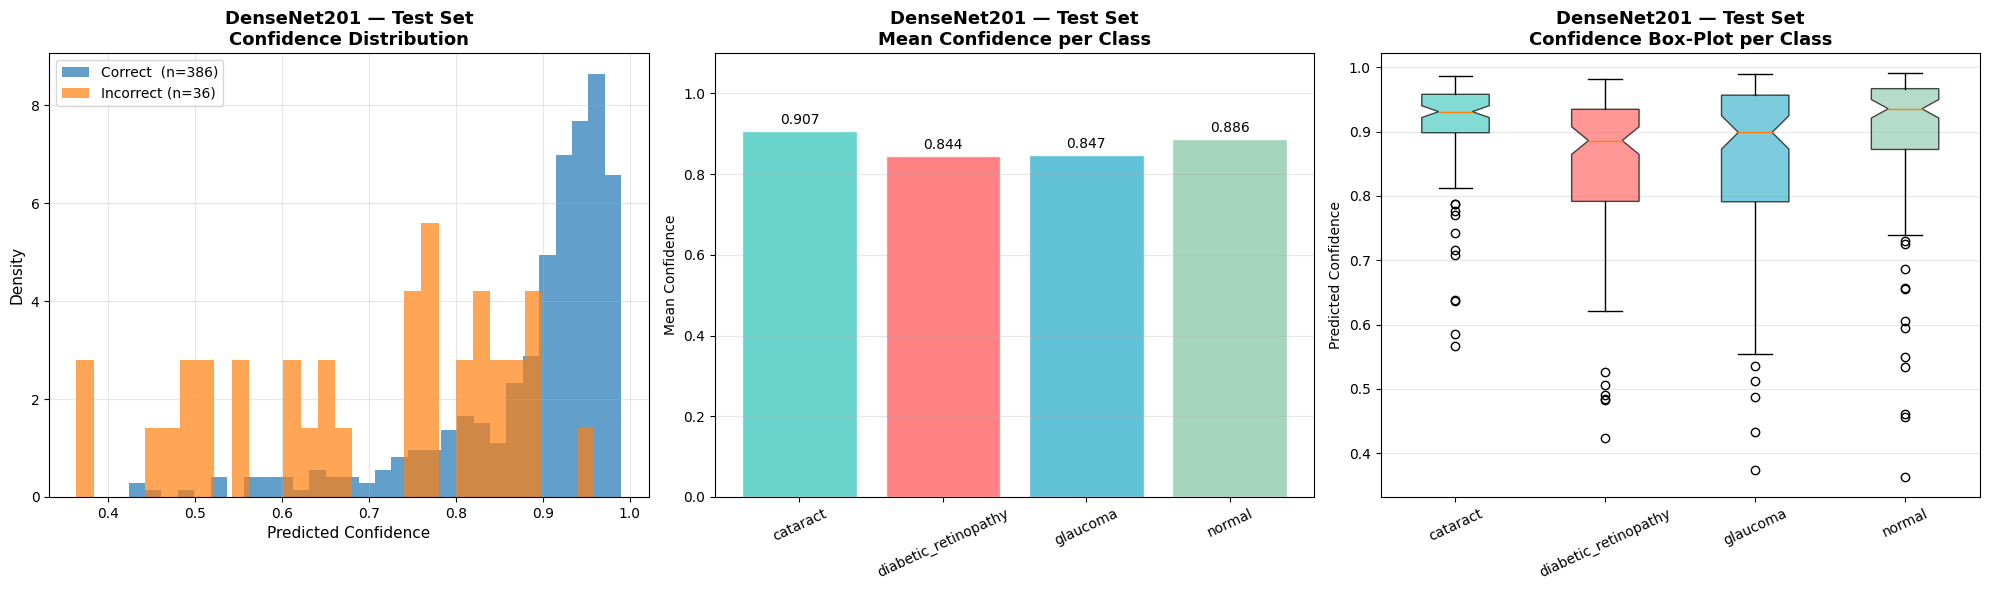


══════════════════════════════════════════════════════════════════════
6. BOOTSTRAP CONFIDENCE INTERVALS  (n=1000, 95% CI)
══════════════════════════════════════════════════════════════════════


TypeError: only integer scalar arrays can be converted to a scalar index

In [12]:
# ═══════════════════════════════════════════════════════════════════
# RUN ALL VISUALISATIONS  (uses y_true, y_pred, y_pred_prob from Cell 10)
# ═══════════════════════════════════════════════════════════════════

print("\n" + "═"*70)
print("1. DUAL CONFUSION MATRIX")
print("═"*70)
cm = plot_dual_confusion_matrix(y_true, y_pred, class_names,
                                 title='DenseNet201 — Test Set')

print("\n" + "═"*70)
print("2. PER-CLASS METRICS BAR CHART")
print("═"*70)
report = plot_per_class_metrics(y_true, y_pred, class_names,
                                 title='DenseNet201 — Test Set')

print("\n" + "═"*70)
print("3. ROC CURVES")
print("═"*70)
roc_auc_dict, macro_auc = plot_roc_curves(y_true, y_pred_prob, class_names,
                                            title='DenseNet201 — Test Set')

print("\n" + "═"*70)
print("4. PRECISION-RECALL CURVES")
print("═"*70)
ap_scores = plot_precision_recall_curves(y_true, y_pred_prob, class_names,
                                          title='DenseNet201 — Test Set')

print("\n" + "═"*70)
print("5. CONFIDENCE DISTRIBUTION")
print("═"*70)
plot_confidence_distribution(y_true, y_pred, y_pred_prob, class_names,
                              title='DenseNet201 — Test Set')

print("\n" + "═"*70)
print("6. BOOTSTRAP CONFIDENCE INTERVALS  (n=1000, 95% CI)")
print("═"*70)
ci_results = bootstrap_confidence_intervals(y_true, y_pred, class_names,
                                             n_bootstrap=1000, ci=0.95,
                                             title='DenseNet201 — Test Set')

print("\n" + "═"*70)
print("7. CALIBRATION CURVE (RELIABILITY DIAGRAM)")
print("═"*70)
ece_scores = plot_calibration_curve(y_true, y_pred_prob, class_names,
                                     n_bins=10,
                                     title='DenseNet201 — Test Set')

print("\n" + "═"*70)
print("8. K-FOLD RADAR CHART")
print("═"*70)
plot_kfold_radar(fold_metrics, title='DenseNet201')

print("\n" + "═"*70)
print("9. TOP MISCLASSIFIED SAMPLES")
print("═"*70)
plot_top_misclassifications(y_true, y_pred, y_pred_prob, test_gen,
                             class_names, n=12,
                             title='DenseNet201 — Test Set')

print("\n" + "═"*70)
print("10. PREDICTION CONFIDENCE HEATMAP")
print("═"*70)
plot_confidence_heatmap(y_true, y_pred_prob, class_names,
                         title='DenseNet201 — Test Set')

print("\n✅ All visualisations complete.")


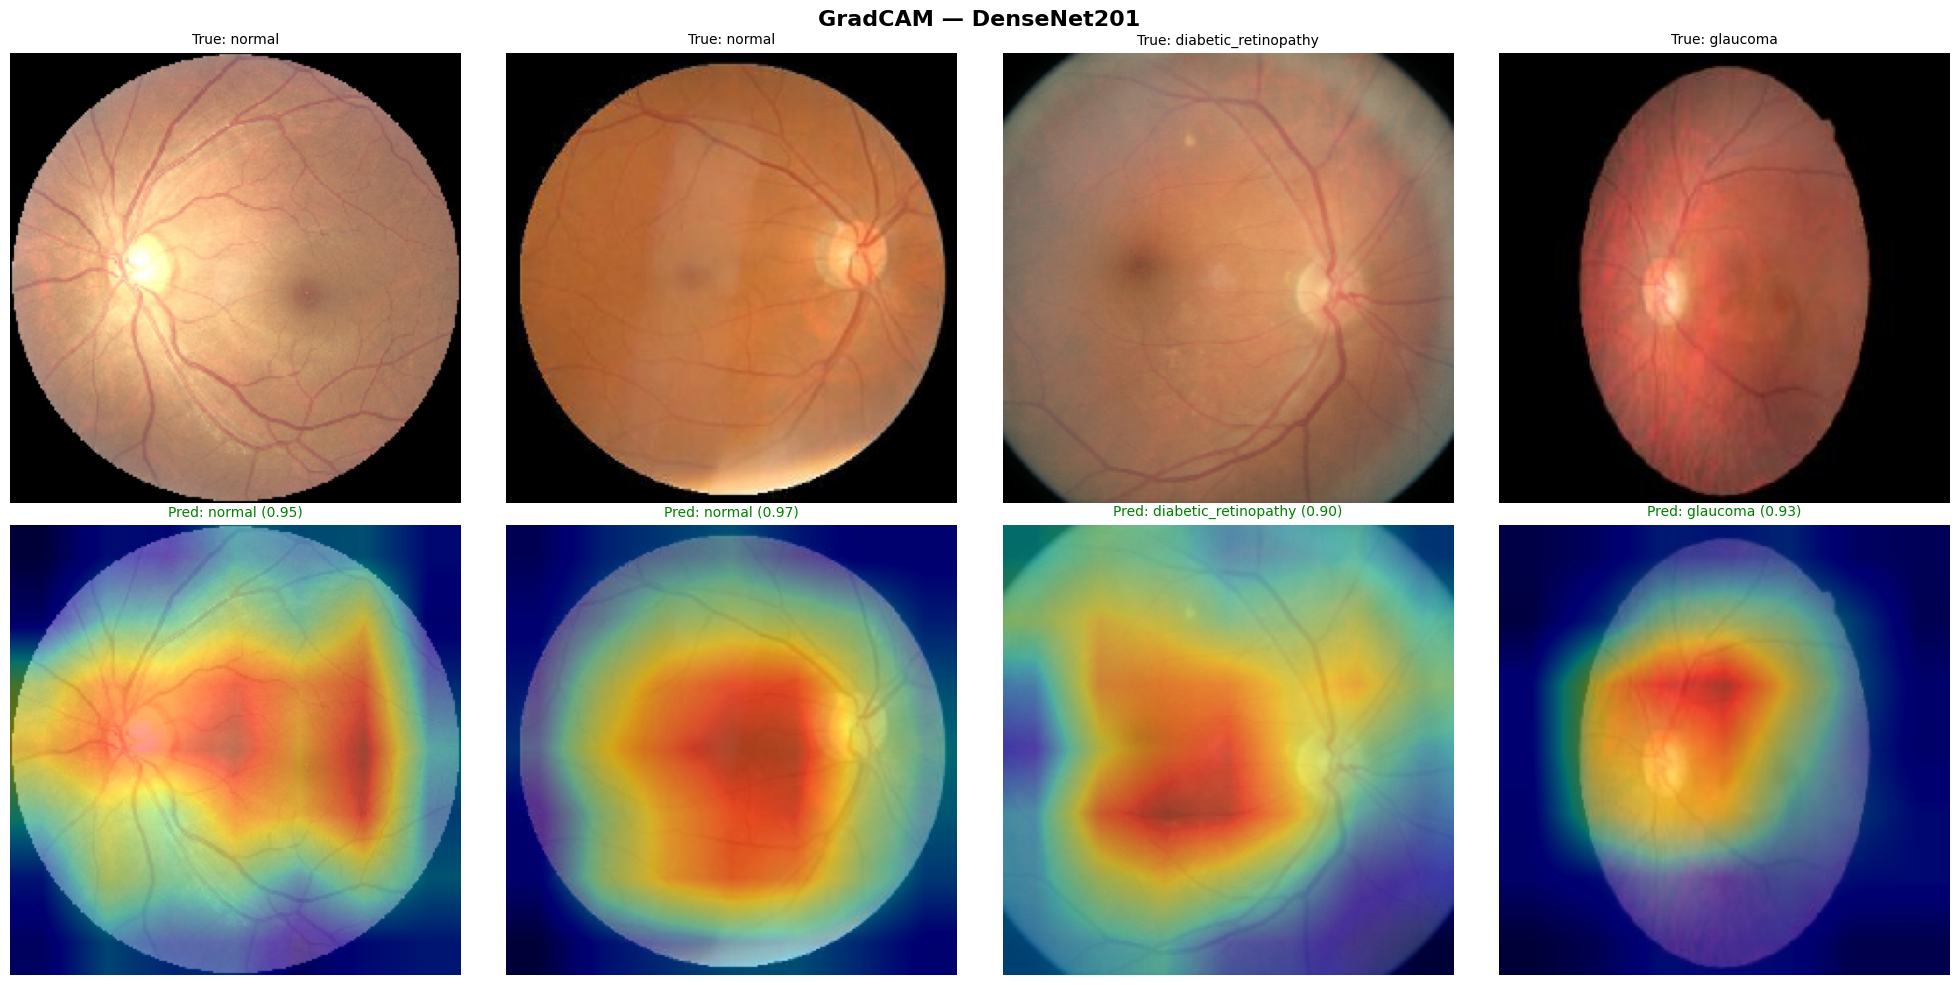

In [13]:
# ─── GradCAM on test images ───────────────────────────────────────────────────
plot_gradcam(best_model, test_gen, class_names, n=4)

In [14]:
# ─── Final Summary ────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("FINAL RESULTS SUMMARY — DenseNet201 (Optimised) with K-Fold CV")
print("="*80)

print("\n[Cross-Validation Results]")
for col in ['accuracy', 'f1_macro', 'precision', 'recall']:
    m = kfold_df[col].mean()
    s = kfold_df[col].std()
    print(f"  CV {col:<12}: {m:.4f} ± {s:.4f}")

print("\n[Hold-out Test Results]")
print(f"  Test Accuracy    : {test_acc:.4f}")
print(f"  Test Top-2 Acc   : {test_top2:.4f}")
print(f"  Test Loss        : {test_loss:.4f}")
print(f"  Test F1 (Macro)  : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"  mAP              : {mean_ap:.4f}")
print(f"  Total Params     : {best_model.count_params():,}")

print("\n[Optimisation Techniques Applied]")
print("  ✔ DenseNet201 backbone (vs. DenseNet121)")
print("  ✔ AdamW optimiser with weight decay (L2 regularisation)")
print("  ✔ Cosine annealing LR schedule with linear warm-up")
print("  ✔ Progressive backbone unfreezing (Phase 1 → Phase 2)")
print("  ✔ Label smoothing (reduces overconfidence)")
print("  ✔ Heavy data augmentation (flip, rotate, zoom, brightness, shift)")
print("  ✔ EarlyStopping + ModelCheckpoint (best weights restored)")
print(f"  ✔ {N_FOLDS}-Fold Stratified Cross Validation")
print("="*80)

# Save results
kfold_df.to_csv('densenet201_kfold_results.csv')
print("\nK-Fold results saved to: densenet201_kfold_results.csv")


FINAL RESULTS SUMMARY — DenseNet201 (Optimised) with K-Fold CV

[Cross-Validation Results]
  CV accuracy    : 0.8998 ± 0.0107
  CV f1_macro    : 0.9003 ± 0.0102
  CV precision   : 0.9088 ± 0.0078
  CV recall      : 0.8988 ± 0.0106

[Hold-out Test Results]
  Test Accuracy    : 0.9147
  Test Top-2 Acc   : 0.9763
  Test Loss        : 0.5518
  Test F1 (Macro)  : 0.9151
  mAP              : 0.9679
  Total Params     : 19,440,964

[Optimisation Techniques Applied]
  ✔ DenseNet201 backbone (vs. DenseNet121)
  ✔ AdamW optimiser with weight decay (L2 regularisation)
  ✔ Cosine annealing LR schedule with linear warm-up
  ✔ Progressive backbone unfreezing (Phase 1 → Phase 2)
  ✔ Label smoothing (reduces overconfidence)
  ✔ Heavy data augmentation (flip, rotate, zoom, brightness, shift)
  ✔ EarlyStopping + ModelCheckpoint (best weights restored)
  ✔ 5-Fold Stratified Cross Validation

K-Fold results saved to: densenet201_kfold_results.csv


In [16]:
model.save("densenet201_retinal_model.h5")

In [18]:
model.save("final_model.keras")
print("Model saved successfully ✅")

Model saved successfully ✅


In [19]:
import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# ✅ Optimization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("densenet201_optimized.tflite", "wb") as f:
    f.write(tflite_model)

print("Optimized TFLite model saved ✅")

Saved artifact at '/tmp/tmpiw4a91g0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133557977583056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133572607391504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133570466142480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133572607390160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133557977594768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133570466152080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133570466151696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133570466141904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133570466146128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133570466151504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133570466142864: Tens

W0000 00:00:1777286667.604629      38 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1777286667.604667      38 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1777286668.182614      38 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


Optimized TFLite model saved ✅
